In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vincentgupo/dengue-cases-in-the-philippines/ph_dengue_cases2016-2020.csv


# Project Description

Developed a time‑series forecasting project on dengue cases in the Philippines using Holt‑Winters exponential smoothing. The model captured long‑term trends and seasonal spikes during rainy months, while multiplicative seasonality ensured realistic, non‑negative forecasts. This work demonstrates how statistical forecasting can be applied to public health data for transparent, actionable insights.

## DATA TRANSFORMATION ##

In [2]:
df = pd.read_csv("/kaggle/input/datasets/vincentgupo/dengue-cases-in-the-philippines/ph_dengue_cases2016-2020.csv")

df.head(3)

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0


### Renaming the columns ###

Renamed the columns to be more appropriate to csv-column appropriate names.

In [3]:
df = df.rename(columns={
    "Month":"month",
    "Year":"year",
    "Region":"region",
    "Dengue_Cases":"dengue_cases",
    "Dengue_Deaths":"dengue_deaths"
})

df.head(3)

,month,year,region,dengue_cases,dengue_deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0


### Describing the values ###

Scanning the values and aggregates of the columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   month          1020 non-null   object
 1   year           1020 non-null   int64 
 2   region         1020 non-null   object
 3   dengue_cases   1020 non-null   int64 
 4   dengue_deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [5]:
df.describe()

,year,dengue_cases,dengue_deaths
count,1020.000000,1020.000000,1020.000000
mean,2018.000000,1124.926471,16.513725
std,1.414907,1662.608878,96.358215
min,2016.000000,10.000000,0.000000
25%,2017.000000,247.750000,1.000000
50%,2018.000000,582.500000,3.000000
75%,2019.000000,1284.250000,7.000000
max,2020.000000,21658.000000,1651.000000


### Remapping the month into numberss ###

Remapped the columns into numeric format and add them into a new column.

In [6]:
df["month_num"] = df["month"].map({
    "January":1,
    "February":2,
    "March":3,
    "April":4,
    "May":5,
    "June":6,
    "July":7,
    "August":8,
    "September":9,
    "October":10,
    "November":11,
    "December":12
})

df["month_num"].value_counts()

month_num
1     85
2     85
3     85
4     85
5     85
6     85
7     85
8     85
9     85
10    85
11    85
12    85
Name: count, dtype: int64

### Creating the datetime column ###

Create a new column containing the "start of month" values for time series analysis.

In [7]:
df["month_year"] = pd.to_datetime(
    dict(
        year=df["year"],
        month=df["month_num"],
        day=1
    )
)

df.head(5)

,month,year,region,dengue_cases,dengue_deaths,month_num,month_year
0,January,2016,Region I,705,1,1,2016-01-01
1,February,2016,Region I,374,0,2,2016-02-01
2,March,2016,Region I,276,0,3,2016-03-01
3,April,2016,Region I,240,2,4,2016-04-01
4,May,2016,Region I,243,1,5,2016-05-01


## EXPLORATORY DATA ANALYSIS ##

### Time Series (2016 - 2020) ###

Plotting the total dengue cases per year.

### Dengue Cases per Year ###

Visualizing and plotting the total dengue cases vs dengue deaths per year. Visualizing and plotting the total dengue cases per year. The number of dengue cases showed a very sharp decline from 2016-2017 due to the Department of Health's increased campaign against dengue. After that, the dengue cases did not reach higher than 200,000 per year. Ultimately, the pandemic slowed down dengue cases contraction due to limited mobility, decreased reporting, and less opportunities for contracting the disease.

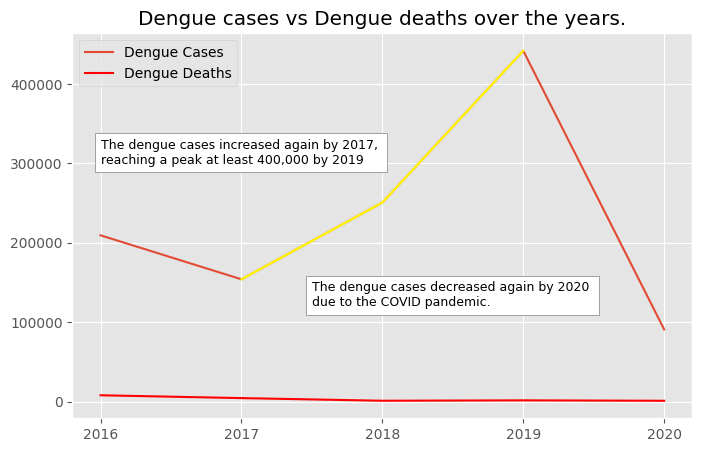

In [8]:
### Plotting dengue cases and deaths per year

## df

viz_df = df.groupby("year")[["dengue_cases","dengue_deaths"]].sum()
viz_df = viz_df.reset_index()

### axes

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_cases"]
viz_df_z = viz_df["dengue_deaths"]

### plotting 

plt.figure(figsize=(8,5))
plt.plot(
    viz_df_x,
    viz_df_y,
    label="Dengue Cases"
)

plt.plot(
    viz_df_x,
    viz_df_z,
    label="Dengue Deaths",
    color="red"
)


### annotate

viz_df_annot = df.groupby("year")["dengue_cases"].sum()
viz_df_annot = viz_df_annot.reset_index()
viz_df_annot = viz_df_annot[(viz_df_annot["year"] >= 2017) & (viz_df_annot["year"] <= 2019)]


viz_df_annot_x = viz_df_annot["year"]
viz_df_annot_y = viz_df_annot["dengue_cases"]

plt.plot(
    viz_df_annot_x,
    viz_df_annot_y,
    color="yellow"
)

plt.text(
    2016,300_000,
    "The dengue cases increased again by 2017, \nreaching a peak at least 400,000 by 2019",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.text(
    2017.5,120_000,
    "The dengue cases decreased again by 2020 \ndue to the COVID pandemic.",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.title("Dengue cases vs Dengue deaths over the years.")


plt.xticks(viz_df_x)
plt.legend()

plt.show()

### Dengue Deaths per Year ###

Plotting the total deaths due to dengue.

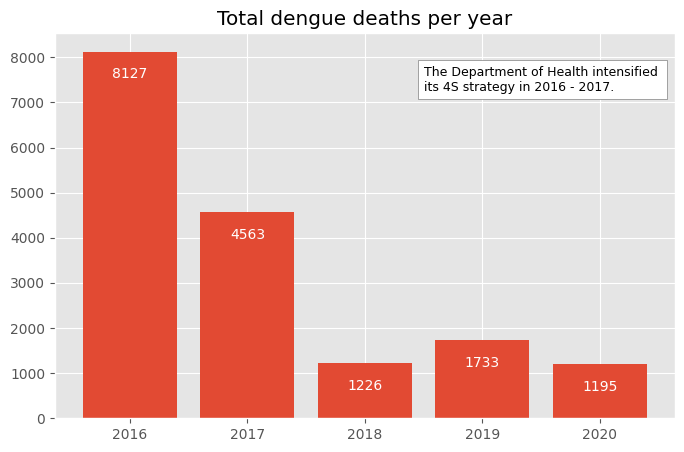

In [9]:
## Visualizing the total dengue cases per year

## axes

viz_df = df.groupby("year")["dengue_deaths"].sum()
viz_df = pd.DataFrame(viz_df).reset_index()

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_deaths"]

## chart

plt.figure(figsize=(8,5))
plt.bar(viz_df_x, viz_df_y)

## annotate

plt.title("Total dengue deaths per year")

for x, y in zip(viz_df_x, viz_df_y):
    plt.text(
        x, y - 500,
        y,
        color="white",
        va="center",
        ha="center"
    )

plt.text(
    2018.5, 7500,
    "The Department of Health intensified \nits 4S strategy in 2016 - 2017.",
    va="center",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)


plt.show()

### Dengue Death Rate per Year ###

Mortality Rate (death / cases) due to Dengue per year. The death rates continued to decrease until it bounce back during the pandemic. 1 out of every 100 dengue cases resulted in death in 2020.

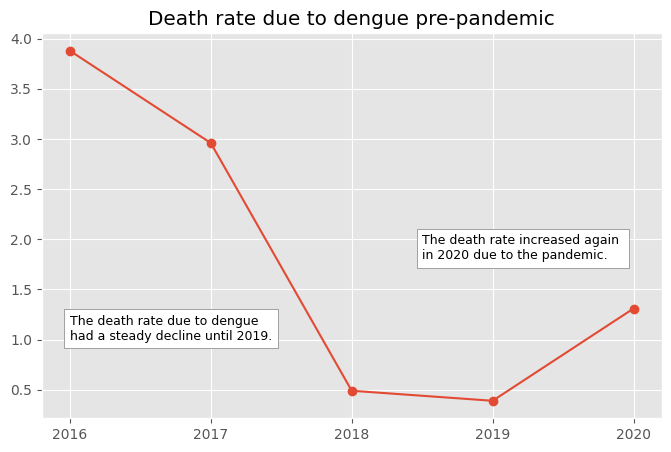

In [10]:
### death rate per year


## axes
viz_df = df.groupby("year")[["dengue_deaths", "dengue_cases"]].sum()
viz_df = viz_df.reset_index()
viz_df["dengue_death_rate"] = (viz_df["dengue_deaths"] / viz_df["dengue_cases"]) * 100
viz_df["dengue_death_rate"] = round(viz_df["dengue_death_rate"], 2)

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_death_rate"]

## charts

plt.figure(figsize=(8,5))

plt.plot(
    viz_df_x,
    viz_df_y,
    marker="o"
)

plt.xticks(viz_df_x)

## annotate

plt.text(
    2016, 1.0,
    "The death rate due to dengue \nhad a steady decline until 2019.",
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    ),
    size=9
)

plt.text(
    2018.5, 1.8,
    "The death rate increased again \nin 2020 due to the pandemic.",
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    ),
    size=9
)

plt.title("Death rate due to dengue pre-pandemic")

plt.show()

## Analysis of NCR Dengue Case Trends ##

#### Isolating the NCR dataset ####

In [11]:
## isolating NCR data
df_ncr = df[df["region"] == "NCR"]

df_ncr.head(5)

,month,year,region,dengue_cases,dengue_deaths,month_num,month_year
840,January,2016,NCR,1261,4,1,2016-01-01
841,February,2016,NCR,999,7,2,2016-02-01
842,March,2016,NCR,730,3,3,2016-03-01
843,April,2016,NCR,448,2,4,2016-04-01
844,May,2016,NCR,414,0,5,2016-05-01


### Plotting the yearly dengue cases for NCR ###

Unlike the national trend, the dengue cases in NCR continued to increase throughout the years before drammatically decreasing in 2020. It would appear the urbanized areas of NCR has made it a perfect breeding ground for mosquitoes all through the time. However, the number of dengue cases decreased in 2020 most likely due to limited mobility and reporting during the pandemic.

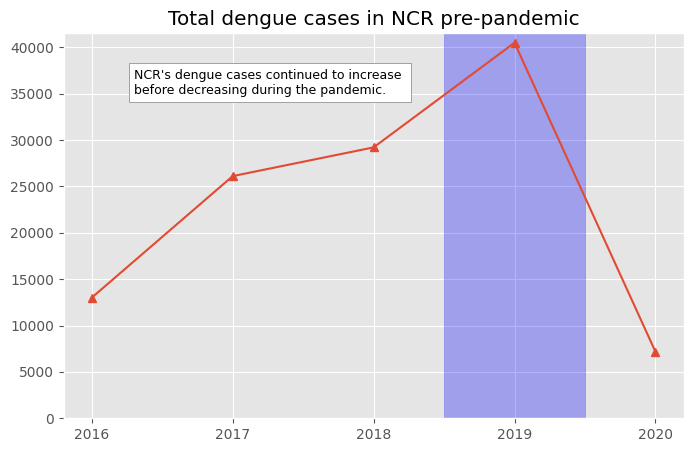

In [12]:
## yearly dengue cases 

## axes

viz_df = df_ncr.groupby("year")["dengue_cases"].sum()
viz_df = viz_df.reset_index()

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_cases"]

## plot

plt.figure(figsize=(8,5))
plt.plot(
    viz_df_x,
    viz_df_y,
    marker="^"
)

## annotate

plt.xticks(viz_df_x)
plt.title("Total dengue cases in NCR pre-pandemic")

plt.text(
    2016.3, 35_000,
    "NCR's dengue cases continued to increase \nbefore decreasing during the pandemic.",
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    ),
    size=9
)

plt.ylim(0,41_500)

plt.fill_between(
    (2018.5, 2019.5),
    41_500,
    color="blue",
    alpha=0.3
)

plt.show()

### Plotting the YoY NCR dengue cases ###

It appears there is a seasonal trend with the year over year dengue cases: the number of dengue cases dips during drier seasons (March - April - May) as there's less breeding grounds for mosquitoes. On the other hand, rainy or wetter seasons (June - September), the number of dengue cases exponentially increase due to rains leaving more breeding areas for mosquitoes.

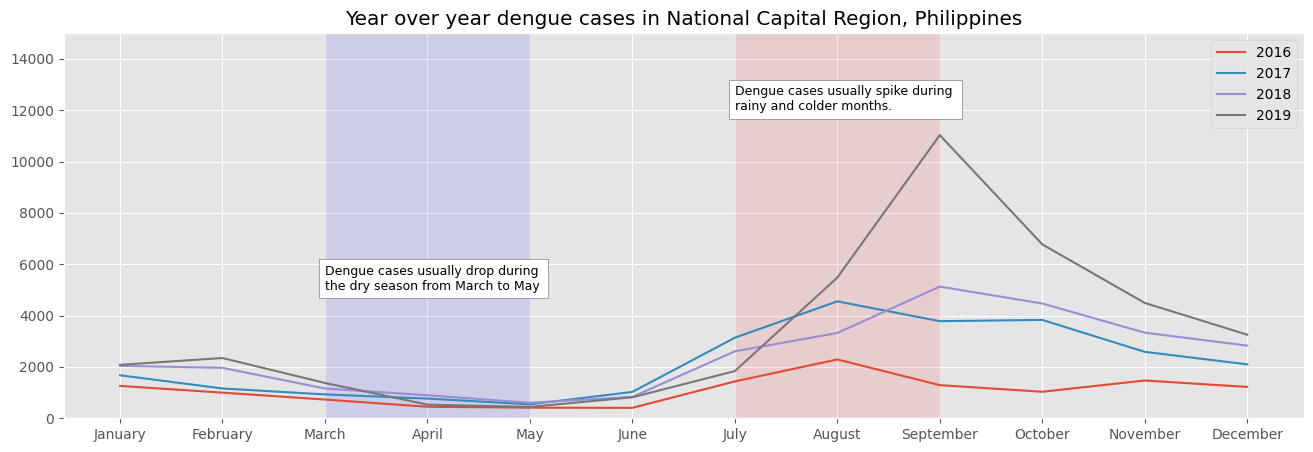

In [13]:
## plotting the yoy cases

## plot

plt.figure(figsize=(16,5))

for year in range(0, 4):
    plot_year = 2016 + year

    viz_df = df_ncr[df_ncr["year"] == plot_year]
    viz_df_x = viz_df["month"]
    viz_df_y = viz_df["dengue_cases"]
    plt.plot(viz_df_x, viz_df_y, label=plot_year)



## annotate



plt.title("Year over year dengue cases in National Capital Region, Philippines")
plt.ylim(0, 15_000)
plt.fill_between(
    (2, 4),
    15_000,
    color="blue",
    alpha=0.1
)

plt.fill_between(
    (6, 8),
    15_000,
    color="red",
    alpha=0.1
)

plt.text(
    2, 5_000,
    "Dengue cases usually drop during \nthe dry season from March to May",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.text(
    6, 12_000,
    "Dengue cases usually spike during \nrainy and colder months.",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.legend()
plt.show()

## Forecasting Numbers ##

### Shaping the dataset ###

Shaping the dataset to make it usable for forecasting.

In [14]:
df_ncr = df_ncr[["month_year","dengue_cases"]]

df_ncr = df_ncr.set_index("month_year")
df_ncr.head(5)

,dengue_cases
month_year,
2016-01-01,1261
2016-02-01,999
2016-03-01,730
2016-04-01,448
2016-05-01,414


### Using Holt-Winters ###

Because a seasonality has been identified, Holt-Winters exponential smoothing was used for the forecasting method.

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(df_ncr["dengue_cases"],
                             trend="add",
                            seasonal="mul",
                            seasonal_periods=12
                            )
model = model.fit()

df_forecast = model.forecast(24)

df_forecast = pd.DataFrame(df_forecast)
df_forecast = df_forecast.rename(columns={
    0:"dengue_cases"
})

df_forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,dengue_cases
2021-01-01,554.274871
2021-02-01,527.028665
2021-03-01,336.174330
2021-04-01,200.999293
2021-05-01,181.351735
2021-06-01,312.501273
2021-07-01,933.021498
2021-08-01,1567.608896
2021-09-01,2326.921224
2021-10-01,1648.296156


### Combining the forecast and original data ###

The forecasts and the original data have been combined to one dataframe.

In [16]:
df_all = pd.concat([df_ncr, df_forecast])
df_all = df_all.reset_index()
df_all = df_all.rename(columns={
    "index":"date"
})

df_all.head(5)

,date,dengue_cases
0,2016-01-01,1261.0
1,2016-02-01,999.0
2,2016-03-01,730.0
3,2016-04-01,448.0
4,2016-05-01,414.0


### Adding a year column ###

Additional transformations were done to the new dataframe.

In [17]:
## adding the year column

df_all["date"] = pd.to_datetime(df_all["date"])

df_all["year"] = df_all["date"].dt.year
df_all["month"] = df_all["date"].dt.month

df_all.head(5)

,date,dengue_cases,year,month
0,2016-01-01,1261.0,2016,1
1,2016-02-01,999.0,2016,2
2,2016-03-01,730.0,2016,3
3,2016-04-01,448.0,2016,4
4,2016-05-01,414.0,2016,5


### Visualizing the data and forecasts according to year ###

According to the forecasts, the dengue cases from 2020 are bound to increase further in 2021 and 2022.

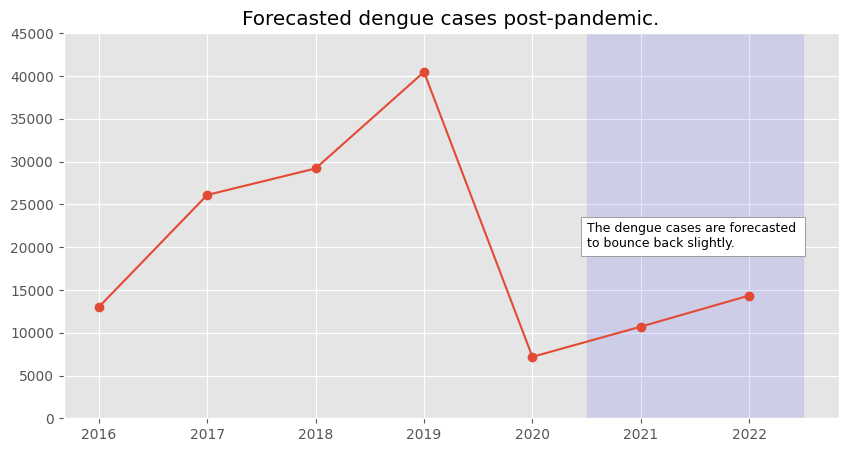

In [18]:
viz_df = df_all.groupby("year")["dengue_cases"].sum()
viz_df = viz_df.reset_index()

## axes

viz_df_x = viz_df["year"]
viz_df_y = viz_df["dengue_cases"]

plt.figure(figsize=(10,5))
plt.plot(
    viz_df_x,
    viz_df_y,
    marker="o"
)

## annotate 

plt.title("Forecasted dengue cases post-pandemic.")
plt.ylim(0,45_000)
plt.fill_between(
    (2020.5, 2022.5),
    45_000,
    color="blue",
    alpha=0.1
)

plt.text(
    2020.5, 20_000,
    "The dengue cases are forecasted \nto bounce back slightly.",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)


plt.show()

### Remapping the month column to be names 

Additional transformations to the tool.

In [19]:
df_all["month_name"] = df_all["month"].map({
    1:"January",
    2:"February",
    3:"March",
    4:"April",
    5:"May",
    6:"June",
    7:"July",
    8:"August",
    9:"September",
    10:"October",
    11:"November",
    12:"December"
})

df_all["month_name"].value_counts()

month_name
January      7
February     7
March        7
April        7
May          7
June         7
July         7
August       7
September    7
October      7
November     7
December     7
Name: count, dtype: int64

### Adding a month-year column ###

Additional transformations were done to the new dataframe.

In [20]:
df_all["month_year"] = df_all["month_name"].astype(str) + "-" + df_all["year"].astype(str)
df_all.head(3)

,date,dengue_cases,year,month,month_name,month_year
0,2016-01-01,1261.0,2016,1,January,January-2016
1,2016-02-01,999.0,2016,2,February,February-2016
2,2016-03-01,730.0,2016,3,March,March-2016


### Visualizing the month over month trends including forecast ###

The month over month in 2021 and 2022 still followed the seasonal dips and spikes as expected.

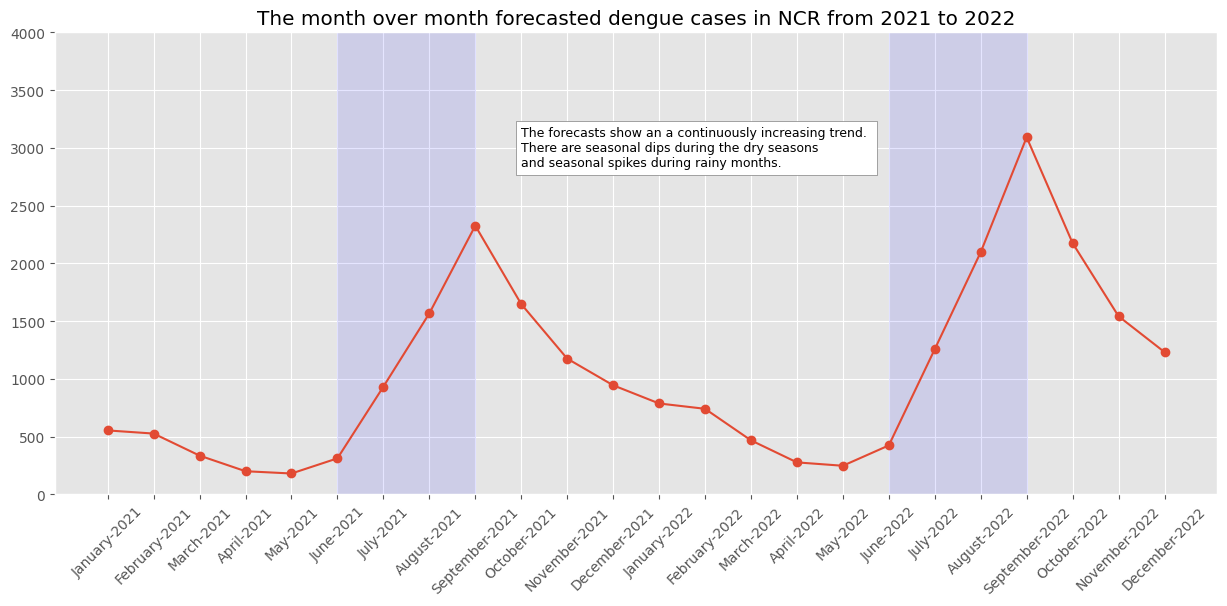

In [21]:
## axes 

df_forecast = df_all[df_all["year"] >= 2021]

viz_df = df_forecast[["month_year", "dengue_cases"]]


viz_df_x = viz_df["month_year"]
viz_df_y = viz_df["dengue_cases"]

## plot

plt.figure(figsize=(15,6))
plt.plot(
    viz_df_x,
    viz_df_y,
    marker='o'
)

## annotate

plt.title("The month over month forecasted dengue cases in NCR from 2021 to 2022")

plt.fill_between(
    (5,8),
    4000,
    color="blue",
    alpha=0.1
)

plt.fill_between(
    (17,20),
    4000,
    color="blue",
    alpha=0.1
)

plt.text(
    9, 3000,
    "The forecasts show an a continuously increasing trend. \nThere are seasonal dips during the dry seasons \nand seasonal spikes during rainy months.",
    va="center",
    size=9,
    bbox=dict(
        facecolor="white",
        edgecolor="gray"
    )
)

plt.xticks(rotation=45)
plt.ylim(0,4000)
plt.show()